Classificacao de Instrumentos

In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import joblib


1. Carregamento

In [2]:
# Mapeia instrumentos para labels
CLASSES = {'vio': 0, 'pia': 1, 'cla': 2}
BASE_PATH = Path("datasets")

In [3]:
def carregar_audio(caminho_arquivo, sr=22050):
    y, _ = librosa.load(caminho_arquivo, sr=sr)

    # normalizacao de amplitude
    y = y / (np.max(np.abs(y)) + 1e-8)
    return y

# Mapeia instrumentos para labels
CLASSES = {'vio': 0, 'pia': 1, 'cla': 2}
BASE_PATH = Path("datasets")

In [4]:
def plot_spectrum(y, sr, instrumento):
    Y = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), d=1/sr)

    plt.title(f"Espectrograma do {instrumento}")
    plt.plot(freqs, Y)
    plt.xlabel("Frequência (Hz)")
    plt.show()

In [5]:
y_vio = carregar_audio(BASE_PATH / "vio" / "[vio][cla]2095__2.wav")
y_cla = carregar_audio(BASE_PATH / "cla" / "[cla][cla]0150__2.wav")
y_pia = carregar_audio(BASE_PATH / "pia" / "[pia][cla]1283__2.wav")

c:\Users\kamil\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
y_pia

array([ 0.07001851,  0.08726916,  0.05531862, ..., -0.25977692,
       -0.26035088, -0.1610971 ], shape=(66150,), dtype=float32)

Espectogramas dos instrumentos

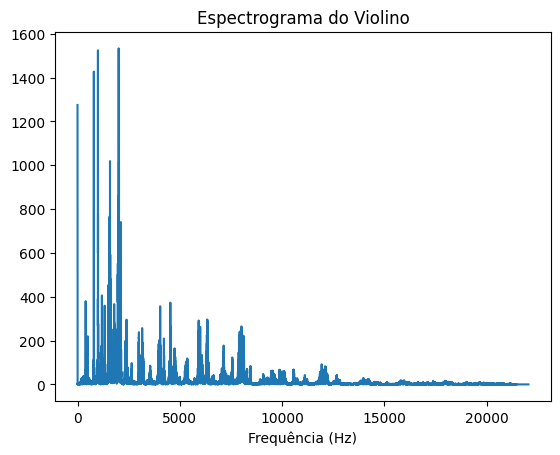

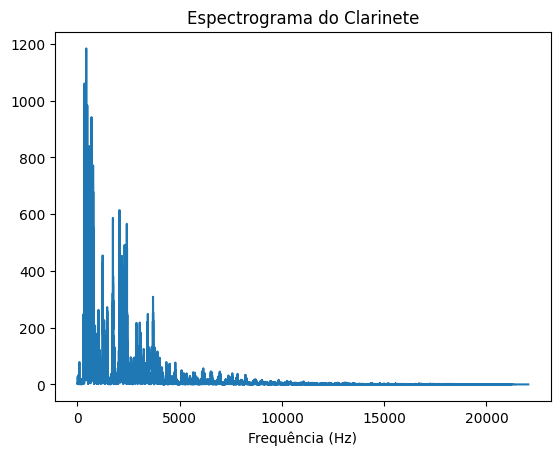

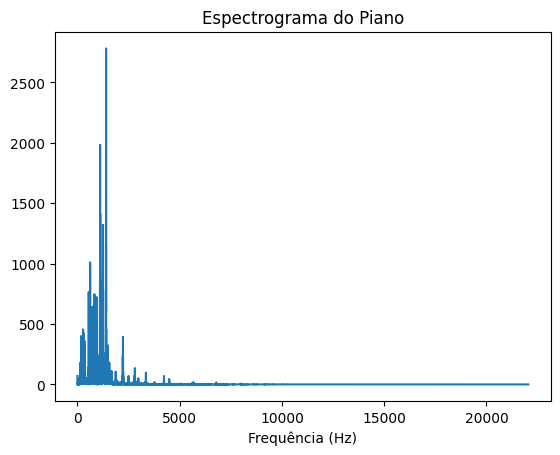

In [7]:
plot_spectrum(y_vio, 44100,instrumento="Violino")
plot_spectrum(y_cla, 44100,instrumento="Clarinete")
plot_spectrum(y_pia, 44100,instrumento="Piano")

Gráfico com frequência e limiares de f_max

piano: 100%|██████████| 721/721 [00:50<00:00, 14.21it/s]


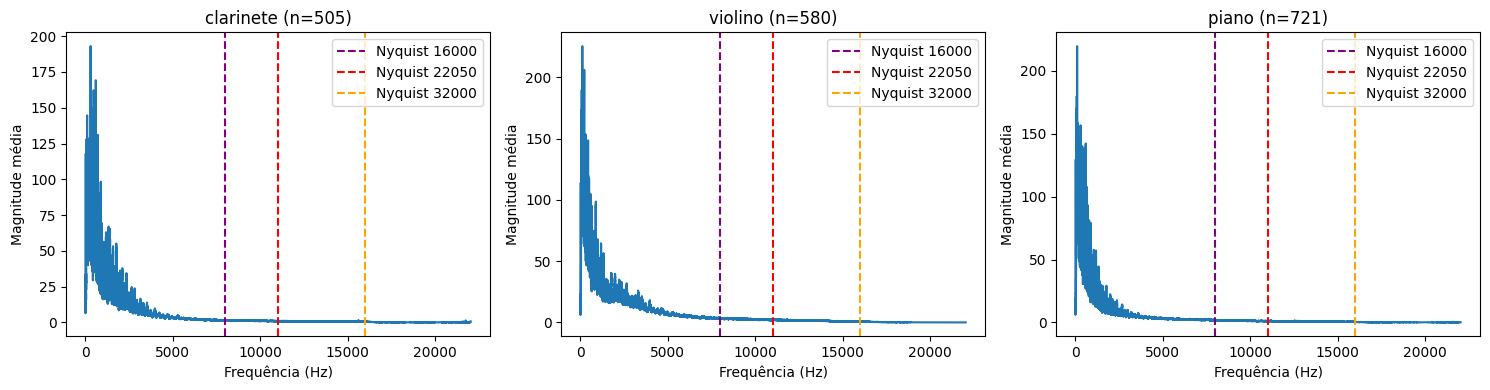

In [8]:
pastas = {
    'clarinete': 'datasets/cla',
    'violino':   'datasets/vio',
    'piano':     'datasets/pia'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, pasta) in zip(axes, pastas.items()):
    arquivos = [f for f in os.listdir(pasta) if f.endswith('.wav')]
    
    espectros = []
    for arquivo in tqdm(arquivos, desc=nome):
        caminho = os.path.join(pasta, arquivo)
        y, sr = librosa.load(caminho, sr=44100, mono=True, duration=3.0)
        Y = np.abs(np.fft.rfft(y))
        espectros.append(Y)
    
    Y_medio = np.mean(espectros, axis=0)
    freqs = np.fft.rfftfreq(len(y), d=1/sr)
    
    ax.plot(freqs, Y_medio)
    ax.axvline(8000, color="purple", linestyle='--', label='Nyquist 16000')
    ax.axvline(11025, color='red',    linestyle='--', label='Nyquist 22050')
    ax.axvline(16000, color='orange', linestyle='--', label='Nyquist 32000')
    ax.set_title(f'{nome} (n={len(arquivos)})')
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude média')
    ax.legend()

plt.tight_layout()
plt.show()

2. Extracao de Features

In [9]:
from utils.extrair_atributos import extract_feature

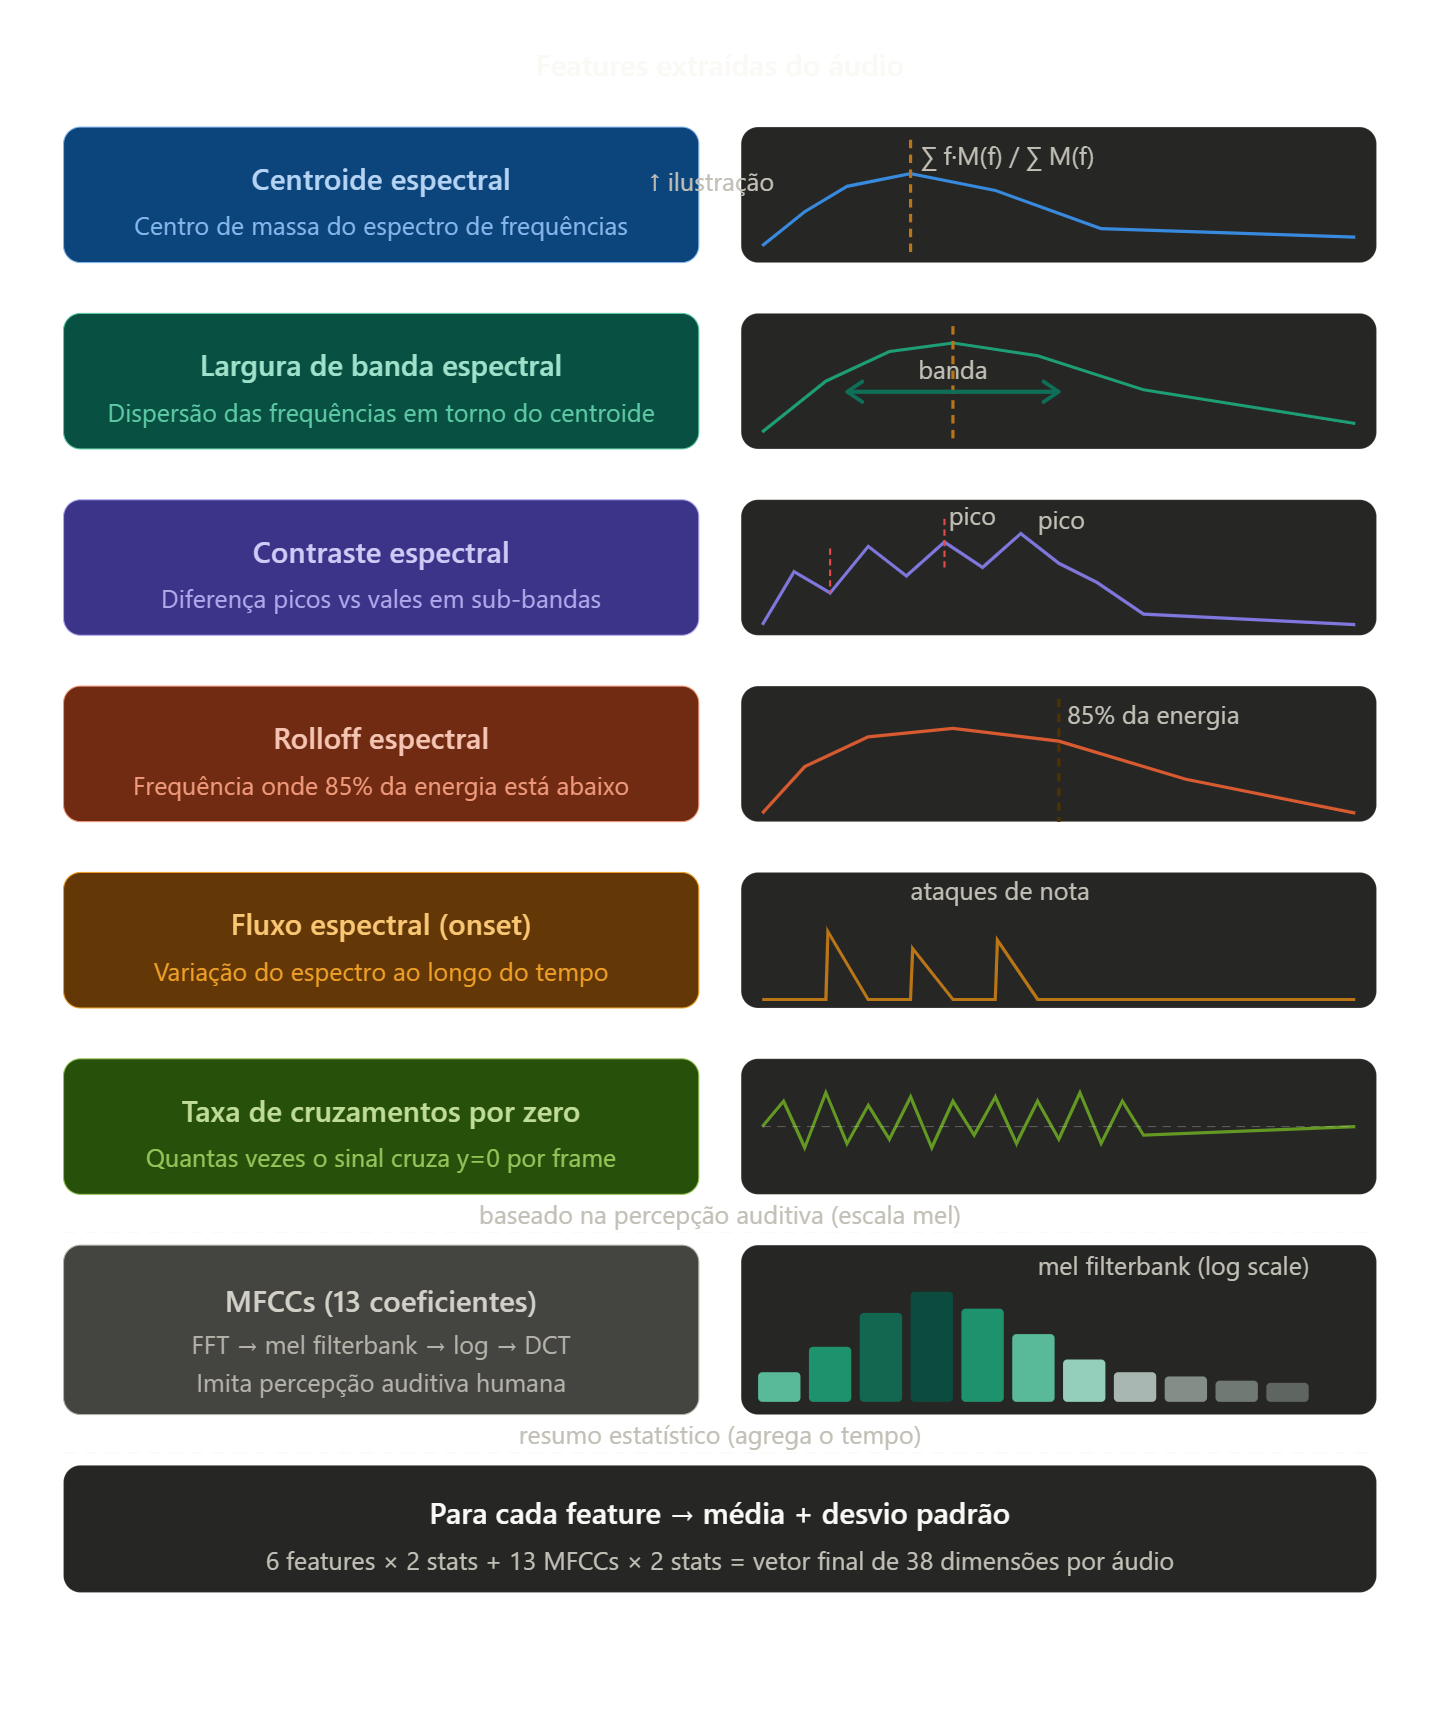

3. Montagem de dataset

In [10]:
def get_feature_names():
    names = []
    
    timbre_features = [
        'spectral_centroid', 'spectral_bandwidth',
        'spectral_contrast', 'spectral_rolloff',
        'spectral_flux', 'zero_crossing'
    ]
    
    for f in timbre_features:
        names.append(f'{f}_mean')
        names.append(f'{f}_std')
    
    for i in range(13):
        names.append(f'mfcc_{i}_mean')
        names.append(f'mfcc_{i}_std')
    
    return names  # 38 nomes no total

def build_dataset():
    rows = []
    col_names = get_feature_names()
    
    for classe, label in CLASSES.items():
        pasta = BASE_PATH / classe
        arquivos = list(pasta.glob("*.wav"))
        
        for arquivo in tqdm(arquivos, desc=classe):
            y = carregar_audio(arquivo)
            features = extract_feature(y)
            
            row = {'arquivo': arquivo.name, 'instrumento': classe, 'label': label}
            row.update(dict(zip(col_names, features)))
            rows.append(row)
    
    return pd.DataFrame(rows)

In [11]:
df_features = build_dataset()

cla: 100%|██████████| 505/505 [00:37<00:00, 13.56it/s]


In [12]:
feature_cols = get_feature_names()

In [13]:
X = df_features[feature_cols].values   # shape: (n_amostras, 38)
y = df_features['label'].values  

In [14]:
df_features.shape

(1806, 41)

In [15]:
# Balanceia as classes para o mesmo número de amostras (menor classe)
rng = np.random.default_rng(42)

classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()

idx_bal = []
for c in classes:
    idx_c = np.where(y == c)[0]
    idx_bal.append(rng.choice(idx_c, size=min_count, replace=False))

idx_bal = np.concatenate(idx_bal)
rng.shuffle(idx_bal)

X_bal = X[idx_bal]
y_bal = y[idx_bal]

# Split com estratificação no conjunto já balanceado
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

print("Amostras por classe (balanceado):", np.bincount(y_bal))

Amostras por classe (balanceado): [505 505 505]


In [16]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

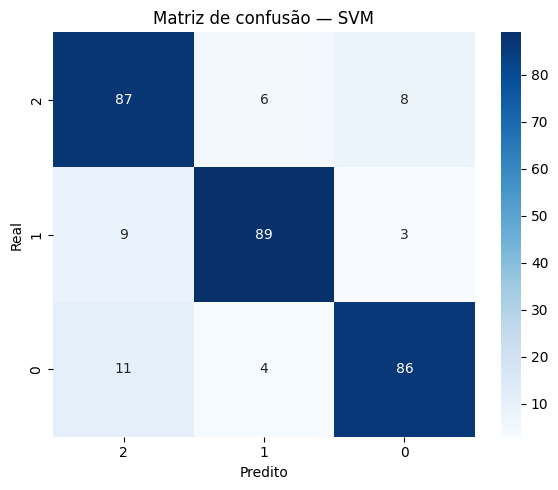

['scaler_instrumentos.pkl']

In [17]:
model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
labels = [CLASSES[i] for i in sorted(CLASSES)]

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels)
plt.title("Matriz de confusão — SVM")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.tight_layout()
plt.show()

joblib.dump(model,  "svm_instrumentos.pkl")
joblib.dump(scaler, "scaler_instrumentos.pkl")

In [18]:
y_pred.shape

(303,)

In [19]:
print("\n── Relatório de classificação ──────────────────")
class_names = ["Violino", "Piano", "Clarinete"]
print(classification_report(y_test, y_pred, target_names=class_names))


── Relatório de classificação ──────────────────
              precision    recall  f1-score   support

     Violino       0.81      0.86      0.84       101
       Piano       0.90      0.88      0.89       101
   Clarinete       0.89      0.85      0.87       101

    accuracy                           0.86       303
   macro avg       0.87      0.86      0.87       303
weighted avg       0.87      0.86      0.87       303



In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, random_state=42)
)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro"
}

scores = cross_validate(
    cv_model,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print(f"Acurácia (treino): {scores['train_accuracy'].mean():.4f} ± {scores['train_accuracy'].std():.4f}")
print(f"Acurácia (validação): {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"F1-macro (validação): {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

Acurácia (treino): 0.9132 ± 0.0045
Acurácia (validação): 0.8416 ± 0.0216
F1-macro (validação): 0.8361 ± 0.0226
